In [38]:
# %load_ext autoreload
# %autoreload 2

import os

from functools import partial

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"

import blackjax
import bayesflow as bf
import jax
import jax.numpy as jnp
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from priors import truncated_normal_rvs
from mcmc import model_nle, warmup, inference_loop_multiple_chains
from plots import create_profile_likelihood_plot, create_pushforward_plot_rdmc
from rdmc import rdmc_experiment_simple
from density import rdmc_approx_likelihood, get_pdf

jax.config.update("jax_enable_x64", True)

In [99]:
def prior_fun_train(
    drift_c_intercept_loc=0.05,
    drift_c_intercept_scale=0.03,
    drift_c_slope_loc=0.5,
    drift_c_slope_scale=0.1,
    amp_shape=10,
    amp_scale=2,
    tau_shape=8,
    tau_scale=10,
    sd_true_shape=80,
    sd_true_scale=0.05,
    threshold_shape=100,
    threshold_scale=0.7,
    t0_loc=300,
    t0_scale=200,
    rng=np.random.default_rng(2025),
):
    drift_c_intercept = truncated_normal_rvs(drift_c_intercept_loc, drift_c_intercept_scale, random_state=rng)
    drift_c_slope = truncated_normal_rvs(drift_c_slope_loc, drift_c_slope_scale, random_state=rng)
    amp = rng.gamma(shape=amp_shape, scale=amp_scale)
    tau = rng.gamma(shape=tau_shape, scale=tau_scale)
    s_true = rng.gamma(shape=sd_true_shape, scale=sd_true_scale)
    b = rng.gamma(shape=threshold_shape, scale=threshold_scale)
    t0 = truncated_normal_rvs(t0_loc, t0_scale, random_state=rng)

    return {
        "v_c_intercept": drift_c_intercept,
        "v_c_slope": drift_c_slope,
        "amp": amp,
        "tau": tau,
        "s_true": s_true,
        "b": b,
        "t0": t0
    }

def simulator_fun(**kwargs):
    return rdmc_experiment_simple(**kwargs, t_max=5000, a_shape=2, s_false=4)


def meta(batch_size):
    num_obs = 500 # np.random.default_rng(2025).integers(250, 750)

    return dict(num_obs=num_obs)

simulator = bf.simulators.make_simulator([prior_fun_train, simulator_fun], meta_fn=meta)

In [100]:
param_names = ["v_c_intercept", "v_c_slope", "tau", "amp", "s_true", "b", "t0"]

test_data = simulator.sample(1)
# test_data["x"][..., 0] *= 1000
prior_draws = np.array([test_data[p] for p in param_names]).squeeze()

0.846


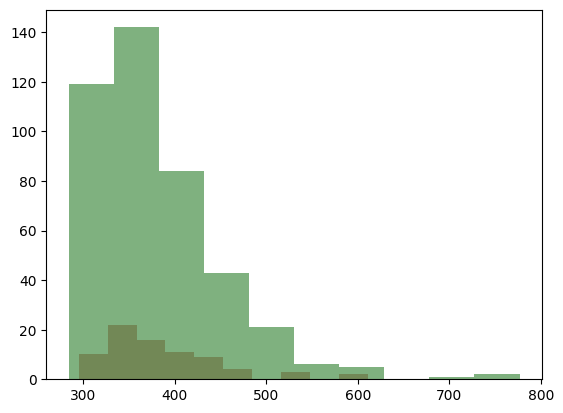

In [101]:
rt, choice = test_data["x"][..., 0], test_data["x"][..., 1]

fig, ax = plt.subplots()

ax.hist(rt[choice==0], alpha = 0.5, color="indianred")
ax.hist(rt[choice==1], alpha = 0.5, color="darkgreen")

print(np.mean(choice))

plt.show()

In [102]:
approximator = keras.saving.load_model("outputs/flow_matching/epochs=10/inference-method=flow_matching/mlp_depth=3/mlp_residual=true/mlp_width=6/model=rdmc_single/checkpoints/model.keras")
approximator.inference_network.integrate_kwargs["steps"] = 100
approximator.inference_network.integrate_kwargs["method"] = "rk45"

In [103]:
def modify_test_data(test_data, idx, acc):
    x = test_data["x"]
    rt = x[..., 0]
    choice = x[..., 1]
    if acc == 1:
        v_c = test_data["v_c_intercept"] + test_data["v_c_slope"]
        s = test_data["s_true"]
    else:
        v_c = test_data["v_c_intercept"]
        s = 4.0


    test_data_new = test_data | dict(x=np.expand_dims(rt[choice==idx], 0), v_c=v_c, s=s)
    del test_data_new["v_c_intercept"]
    del test_data_new["v_c_slope"]
    del test_data_new["s_true"]

    return test_data_new

In [104]:
def approx_pdf(data, t_max=1500.0, dt=5.0):
    # 1. Adjust RT
    rt = data["x"][0]
    decision_time = rt - data["t0"][0]
    
    params = dict(
        mu_c=data["v_c"][0],
        A=data["amp"][0],
        alpha=2.0, tau=data["tau"][0], 
        b=data["b"][0], sigma=data["s"][0]
    )

    # 2. Get PDFs for both accumulators
    t_grid, pdf1 = get_pdf(params, t_max, dt)
    
    # 3. Compute CDFs (Cumulative Sum * dt)
    
    # 4. Find index corresponding to decision time
    # We use soft interpolation or nearest index. For simplicity, nearest:
    idx = jnp.round(decision_time / dt).astype(int) - 1
    
    # Safety clipping for indices
    idx = jnp.clip(idx, 0, len(t_grid)-1)

    # Likelihood if choice == 0
    dens = pdf1[idx]
    
    # Avoid log(0)
    return jnp.log(jnp.maximum(dens, 1e-10))

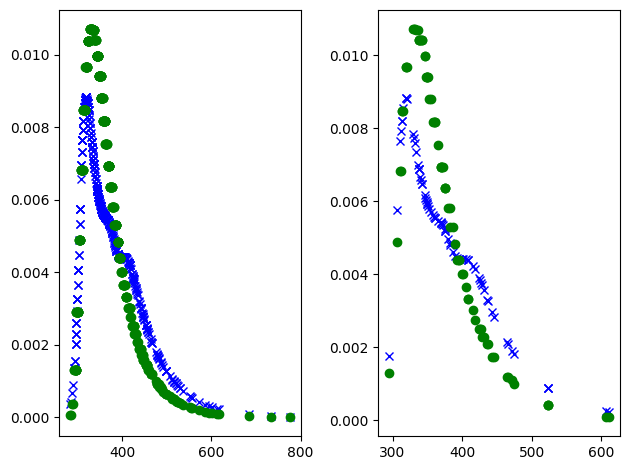

In [105]:
test_data_1 = modify_test_data(test_data, 1, 1)

prob_nle = np.exp(approximator.log_prob(test_data_1)).squeeze()
prob_approx = np.exp(approx_pdf(test_data_1))

fig, (ax1, ax2) = plt.subplots(1, 2)

rt = test_data_1["x"][0]
ax1.plot(rt, prob_nle, "x", color="blue")
ax1.plot(rt, prob_approx, "o", color="green")

test_data_0 = modify_test_data(test_data, 0, 1)
rt = test_data_0["x"][0]

prob_nle = np.exp(approximator.log_prob(test_data_0)).squeeze()
prob_approx = np.exp(approx_pdf(test_data_0))

ax2.plot(rt, prob_nle, "x", color="blue")
ax2.plot(rt, prob_approx, "o", color="green")

fig.tight_layout()

In [106]:
def approx_likelihood(data):
    rt, choice = data["x"][0, :, 0], data["x"][0, :, 1]
    s_false = 4.0
    a_shape = 2.0
    return rdmc_approx_likelihood(
        rt,
        choice,
        data["v_c_intercept"].squeeze(),
        data["v_c_slope"].squeeze(),
        data["amp"].squeeze(),
        data["tau"].squeeze(),
        data["s_true"].squeeze(),
        s_false,
        data["b"].squeeze(),
        data["t0"].squeeze(),
        a_shape,
        2500.0,
        5.0,
    )

approx_likelihood(test_data).sum()

Array(-2988.9192977, dtype=float64)

In [110]:
approximator.inference_network

<FlowMatching name=flow_matching, built=True>

In [112]:
import numpy as np

def approximate_log_cdf_survival(x_grid, log_pdf_values):
    """
    Approximates log CDF and log Survival Function from log PDF values 
    on a grid x using the log-space trapezoidal rule.
    
    Args:
        x_grid: Sorted 1D array of x locations.
        log_pdf_values: 1D array of log(pdf(x)) at those locations.
        
    Returns:
        log_cdf: 1D array of log CDF values at x_grid.
        log_sf:  1D array of log Survival Function (1-CDF) values at x_grid.
    """
    # 1. Calculate the log-area of each trapezoidal slice
    # slice_area = (f(x_i) + f(x_{i+1})) / 2 * dx
    # In log space: log_slice = logaddexp(log_pdf[i], log_pdf[i+1]) + log(dx) - log(2)
    
    # Calculate dx between points (allows non-uniform grid)
    dx = np.diff(x_grid)
    log_dx = np.log(dx)
    
    # Average height in log domain (sum of exps)
    log_avg_height = np.logaddexp(log_pdf_values[:-1], log_pdf_values[1:])
    
    # Log area of each interval
    log_slice_areas = log_avg_height + log_dx - np.log(2)
    
    # 2. Compute Log CDF (Cumulative Sum in log domain)
    # We define CDF at x[0] as roughly 0 (log_cdf = -inf) or integrate from -inf if needed.
    # Here we accumulate areas starting from the first interval.
    log_cdf = np.empty_like(x_grid)
    log_cdf[0] = -np.inf # Assuming probability mass before x[0] is negligible
    
    # np.logaddexp.accumulate isn't a standard function, so we use a loop or cumulative logsumexp
    # For speed on large arrays, we can use a cumulative log-sum-exp trick:
    current_log_sum = -np.inf
    for i in range(len(log_slice_areas)):
        current_log_sum = np.logaddexp(current_log_sum, log_slice_areas[i])
        log_cdf[i+1] = current_log_sum
        
    # Optional: Normalize if the total integral is not exactly 1.0 due to grid truncation
    total_log_mass = log_cdf[-1]
    log_cdf -= total_log_mass
    
    # 3. Compute Log Survival Function (Integration from Right)
    # It is numerically unstable to do log(1 - exp(log_cdf)) for the right tail.
    # Instead, we integrate from the right side (reverse accumulation).
    log_sf = np.empty_like(x_grid)
    log_sf[-1] = -np.inf # Probability of > x_max is assumed negligible
    
    current_log_sum_rev = -np.inf
    for i in range(len(log_slice_areas) - 1, -1, -1):
        current_log_sum_rev = np.logaddexp(current_log_sum_rev, log_slice_areas[i])
        log_sf[i] = current_log_sum_rev
        
    # Normalize Survival function as well
    log_sf -= total_log_mass
    
    return log_cdf, log_sf

In [124]:
_, log_sf = approximate_log_cdf_survival(np.linspace(0, 0.9, 100), jax.scipy.stats.norm.logpdf(np.linspace(0, 1, 100)))
log_sf

array([-2.22044605e-16, -1.18754303e-02, -2.38923494e-02, -3.60529363e-02,
       -4.83594348e-02, -6.08141564e-02, -7.34194837e-02, -8.61778732e-02,
       -9.90918588e-02, -1.12164055e-01, -1.25397162e-01, -1.38793968e-01,
       -1.52357354e-01, -1.66090296e-01, -1.79995877e-01, -1.94077282e-01,
       -2.08337811e-01, -2.22780879e-01, -2.37410028e-01, -2.52228927e-01,
       -2.67241382e-01, -2.82451345e-01, -2.97862915e-01, -3.13480354e-01,
       -3.29308090e-01, -3.45350729e-01, -3.61613062e-01, -3.78100079e-01,
       -3.94816978e-01, -4.11769177e-01, -4.28962328e-01, -4.46402328e-01,
       -4.64095340e-01, -4.82047801e-01, -5.00266445e-01, -5.18758318e-01,
       -5.37530800e-01, -5.56591627e-01, -5.75948913e-01, -5.95611173e-01,
       -6.15587356e-01, -6.35886868e-01, -6.56519612e-01, -6.77496014e-01,
       -6.98827070e-01, -7.20524381e-01, -7.42600202e-01, -7.65067493e-01,
       -7.87939970e-01, -8.11232169e-01, -8.34959512e-01, -8.59138376e-01,
       -8.83786181e-01, -

In [128]:
p = approximator.log_prob(modify_test_data(test_data, 0, 1)).squeeze()

In [142]:
def nle_likelihood(data):
    def modify_test_data(test_data, acc):
        x = test_data["x"]
        rt = x[..., 0]

        if acc == 1:
            v_c = test_data["v_c_intercept"] + test_data["v_c_slope"]
            s = test_data["s_true"]
        else:
            v_c = test_data["v_c_intercept"]
            s = np.array([4.0])[None, :]

        test_data_new = test_data | dict(x=rt, v_c=v_c, s=s)
        del test_data_new["v_c_intercept"]
        del test_data_new["v_c_slope"]
        del test_data_new["s_true"]

        return test_data_new

    choice = data["x"][..., 1].squeeze()

    pdf_true = approximator.log_prob(modify_test_data(data, 1)).squeeze()
    pdf_false = approximator.log_prob(modify_test_data(data, 0)).squeeze()

    rt = modify_test_data(data, 1)["x"].squeeze()
    rt_idx = np.argsort(rt)

    _, sf_true = approximate_log_cdf_survival(rt[rt_idx], pdf_true[rt_idx])
    _, sf_false = approximate_log_cdf_survival(rt[rt_idx], pdf_false[rt_idx])

    dens_true = pdf_true + sf_false
    dens_false = pdf_false + sf_true

    return np.where(choice[rt_idx] == 1, dens_true, dens_false)
    
nle_likelihood(test_data)

/tmp/ipykernel_104629/1724487950.py:22: RuntimeWarning: divide by zero encountered in log
  log_dx = np.log(dx)


array([ -5.42202759,  -4.91466716,  -4.72920001,  -5.72184499,
        -4.74766347,  -4.74101064,  -4.83105626,  -5.81734529,
        -8.52829438,  -5.02612513,  -5.1976859 ,  -6.1747219 ,
        -5.42253911,  -4.9169892 ,  -5.55967128,  -5.13125011,
        -5.1833274 ,  -5.1833274 ,  -5.23889109,  -5.61348686,
        -5.1552206 ,  -6.08026943,  -8.19184933,  -4.77264278,
        -6.02025621,  -5.14820553,  -5.56015135,  -5.32126881,
        -7.04050423,  -7.45394893,  -5.42677493,  -9.48780587,
        -5.41179312,  -5.34152687,  -8.11618092,  -5.98152645,
        -5.23981382,  -4.87482979,  -5.22828772,  -5.22410371,
        -5.04206646,  -6.20813883,  -5.17522133,  -4.98292052,
        -5.51168811,  -6.37494837,  -8.27027402,  -5.09291492,
        -5.18090139,  -5.51197038,  -5.41314683,  -6.24653546,
        -5.31923185,  -5.14998994, -10.20783604,  -6.79229784,
        -5.38560152,  -4.91956329,  -7.4855032 ,  -4.75081465,
        -5.98131499,  -5.37638877,  -4.75081465,  -6.65

/tmp/ipykernel_104629/1724487950.py:22: RuntimeWarning: divide by zero encountered in log
  log_dx = np.log(dx)


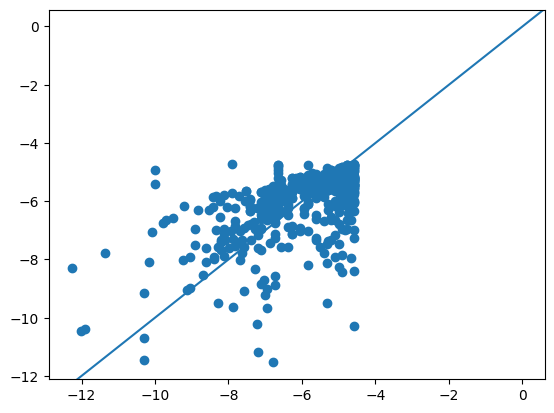

In [144]:
fig, ax = plt.subplots()

ax.scatter(approx_likelihood(test_data)[np.argsort(test_data["x"][0, :, 0])], nle_likelihood(test_data))
ax.axline((0, 0), slope=1)